# Ejercicios KNN

## A. Estudie la clase kNN de la aproximación del vecino más próximo proporcionada en el Jupiter notebook Lab-02 que acompaña a este laboratorio. Tenga en cuenta que esta clase está diseñada para conjuntos de datos con atributos de entrada numéricos.

In [1]:
class kNN():
    def __init__(self, k = 3, exp = 2): 
        self.k = k  # number of neighbor for local class estimation
        self.exp = exp # exponent for the Minkowski distance
      
    def fit(self, X_train, Y_train):
        self.X_train = X_train
        self.Y_train = Y_train   
                
    def getDiscreteClassification(self, X_test): # -> np.ndarray
        Y_pred_test = []

        for i in range(len(X_test)): 
            test_instance = X_test.iloc[i]
            
            distances = []

            for j in range(len(self.X_train)):
                train_instance = self.X_train.iloc[j] 
                distance = self.Minkowski_distance(test_instance, train_instance)
                distances.append(distance) 

            # FIX: Remove index assignment to avoid shape mismatch
            df_dists = pd.DataFrame(data={'dist': distances})

            df_nn = df_dists.sort_values(by=['dist'])
            df_knn = df_nn[:self.k]
            
            predictions = self.Y_train.iloc[df_knn.index].value_counts()
                
            y_pred_test = predictions.index[0]
            Y_pred_test.append(y_pred_test)

        return Y_pred_test

    
    def Minkowski_distance(self, x1, x2): # -> float
        distance = 0

        for i in range(len(x1)):
            distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
        
        distance = distance**(1/self.exp)
    
        return distance
    
    def normalize(self, data): # -> pd.DataFrame
        normalized_data = (data-data.min())/(data.max()-data.min())
        return normalized_data
    
    def getClassProbs(self, X_test): # -> pd.DataFrame

      # Obtenemos las clases únicas ordenadas
      unique_classes = sorted(self.Y_train.unique())

      # Lista para almacenar las probabilidades de cada instancia
      all_probs = []

      # Para cada instancia de prueba
      for i in range(len(X_test)):
          test_instance = X_test.iloc[i]

          # Calculamos distancias a todos los puntos de entrenamiento
          distances = []
          for j in range(len(self.X_train)):
              train_instance = self.X_train.iloc[j]
              distance = self.Minkowski_distance(test_instance, train_instance)
              distances.append(distance)

          # Creamos DataFrame con las distancias
          df_dists = pd.DataFrame(data={'dist': distances})

          # Ordenamos por distancia y tomamos los k vecinos más cercanos
          df_nn = df_dists.sort_values(by=['dist'])
          df_knn = df_nn[:self.k]

          # Contamos ocurrencias de cada clase entre los k vecinos
          class_counts = self.Y_train.iloc[df_knn.index].value_counts()

          # Calculamos probabilidades para cada clase
          probs = []
          for class_label in unique_classes:
              if class_label in class_counts.index:
                  prob = class_counts[class_label] / self.k
              else:
                  prob = 0.0
              probs.append(prob)

          all_probs.append(probs)

      # Creamos DataFrame con todas las probabilidades
      prob_df = pd.DataFrame(all_probs, columns=[f'prob_class_{c}' for c in unique_classes])

      return prob_df

        

In [2]:
import pandas as pd

df = pd.read_csv("glass.csv")
print(df.head())

for clase in df['class'].unique():
    print(clase)

        RI     Na    Mg    Al     Si     K     Ca   Ba    Fe  \
0  1.51793  12.79  3.50  1.12  73.03  0.64   8.77  0.0  0.00   
1  1.51643  12.16  3.52  1.35  72.89  0.57   8.53  0.0  0.00   
2  1.51793  13.21  3.48  1.41  72.64  0.59   8.43  0.0  0.00   
3  1.51299  14.40  1.74  1.54  74.55  0.00   7.59  0.0  0.00   
4  1.53393  12.30  0.00  1.00  70.16  0.12  16.19  0.0  0.24   

                    class  
0      'build wind float'  
1      'vehic wind float'  
2      'build wind float'  
3               tableware  
4  'build wind non-float'  
'build wind float'
'vehic wind float'
tableware
'build wind non-float'
headlamps
containers


## B. Añade a la clase kNN el método normalize que normaliza los atributos de entrada de los datos de entrenamiento X_train y los datos de prueba X_test.

**Glass (Normalizados)**

Text(0, 0.5, 'Accuracy')

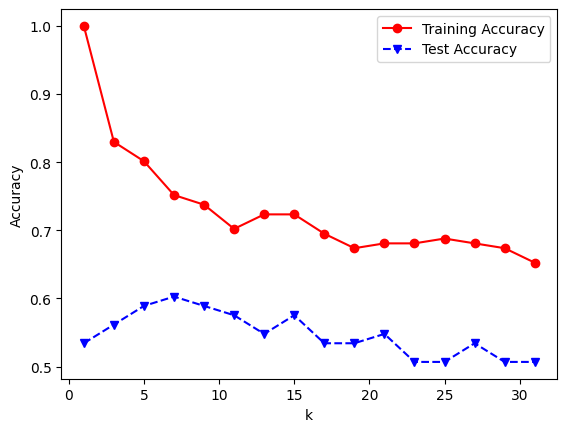

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy.random import random
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('glass.csv')

Y = data['class']
X = data.drop(['class'],axis=1)

# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.34, random_state=10)

k_range = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]

trainAcc = np.zeros(len(k_range))
testAcc = np.zeros(len(k_range))

index = 0 

for j in k_range:
    # knn = kNN(k=j)
    clf = kNN(j)

    # normalize the data
    norm_x = clf.normalize(X_train)
    norm_xtest = clf.normalize(X_test)
    
    # setup the training data
    clf.fit(norm_x, Y_train)
    
    # get the predictions
    Y_predTrain = clf.getDiscreteClassification(norm_x)
    Y_predTest = clf.getDiscreteClassification(norm_xtest)

    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1

# Plot of training and test accuracies
plt.plot(k_range,trainAcc,'ro-',k_range,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('k')
plt.ylabel('Accuracy')



In [16]:
print(trainAcc)
print (testAcc)

[1.         0.82978723 0.80141844 0.75177305 0.73758865 0.70212766
 0.72340426 0.72340426 0.69503546 0.67375887 0.68085106 0.68085106
 0.68794326 0.68085106 0.67375887 0.65248227]
[0.53424658 0.56164384 0.5890411  0.60273973 0.5890411  0.57534247
 0.54794521 0.57534247 0.53424658 0.53424658 0.54794521 0.50684932
 0.50684932 0.53424658 0.50684932 0.50684932]


**B. No Normalizados**

Text(0, 0.5, 'Accuracy')

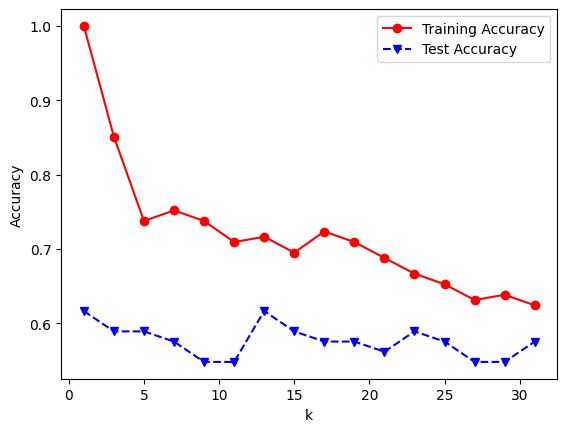

In [17]:

index = 0

for j in k_range:
    # knn = kNN(k=j)
    clf2 = kNN(j)
    
    # setup the training data
    clf2.fit(X_train, Y_train)
    
    # get the predictions
    Y_predTrain = clf2.getDiscreteClassification(X_train)
    Y_predTest = clf2.getDiscreteClassification(X_test)

    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1

# Plot of training and test accuracies
plt.plot(k_range,trainAcc,'ro-',k_range,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('k')
plt.ylabel('Accuracy')

In [18]:
print(trainAcc)
print (testAcc)

[1.         0.85106383 0.73758865 0.75177305 0.73758865 0.70921986
 0.71631206 0.69503546 0.72340426 0.70921986 0.68794326 0.66666667
 0.65248227 0.63120567 0.63829787 0.62411348]
[0.61643836 0.5890411  0.5890411  0.57534247 0.54794521 0.54794521
 0.61643836 0.5890411  0.57534247 0.57534247 0.56164384 0.5890411
 0.57534247 0.54794521 0.54794521 0.57534247]


**Diabetes (Normalizados)**

Text(0, 0.5, 'Accuracy')

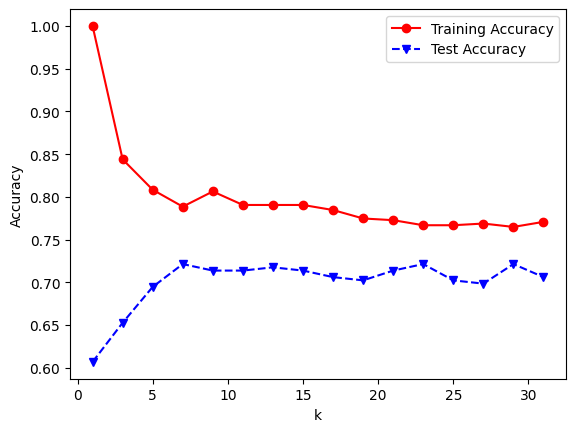

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy.random import random
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Load the dataset
data = pd.read_csv('diabetes.csv')

Y = data['class']
X = data.drop(['class'],axis=1)

# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.34, random_state=10)

k_range = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]

trainAcc = np.zeros(len(k_range))
testAcc = np.zeros(len(k_range))

index = 0 

for j in k_range:
    # knn = kNN(k=j)
    clf = kNN(j)

    # normalize the data
    norm_x = clf.normalize(X_train)
    norm_xtest = clf.normalize(X_test)
    
    # setup the training data
    clf.fit(norm_x, Y_train)
    
    # get the predictions
    Y_predTrain = clf.getDiscreteClassification(norm_x)
    Y_predTest = clf.getDiscreteClassification(norm_xtest)

    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1

# Plot of training and test accuracies
plt.plot(k_range,trainAcc,'ro-',k_range,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('k')
plt.ylabel('Accuracy')

In [4]:
print(trainAcc)
print (testAcc)

[1.         0.84387352 0.8083004  0.78853755 0.80632411 0.79051383
 0.79051383 0.79051383 0.78458498 0.77470356 0.77272727 0.76679842
 0.76679842 0.7687747  0.76482213 0.77075099]
[0.60687023 0.65267176 0.69465649 0.72137405 0.71374046 0.71374046
 0.71755725 0.71374046 0.70610687 0.70229008 0.71374046 0.72137405
 0.70229008 0.69847328 0.72137405 0.70610687]


**No Normalizados**

Text(0, 0.5, 'Accuracy')

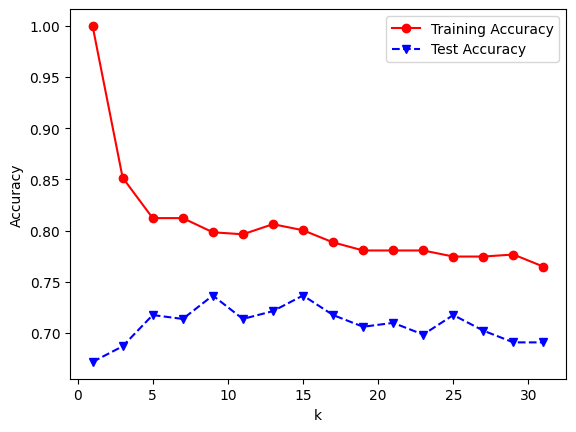

In [5]:
index = 0

for j in k_range:
    # knn = kNN(k=j)
    clf2 = kNN(j)
    
    # setup the training data
    clf2.fit(X_train, Y_train)
    
    # get the predictions
    Y_predTrain = clf2.getDiscreteClassification(X_train)
    Y_predTest = clf2.getDiscreteClassification(X_test)

    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)
    index += 1

# Plot of training and test accuracies
plt.plot(k_range,trainAcc,'ro-',k_range,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('k')
plt.ylabel('Accuracy')

In [6]:
print(trainAcc)
print (testAcc)

[1.         0.85177866 0.81225296 0.81225296 0.79841897 0.79644269
 0.80632411 0.80039526 0.78853755 0.78063241 0.78063241 0.78063241
 0.77470356 0.77470356 0.77667984 0.76482213]
[0.67175573 0.6870229  0.71755725 0.71374046 0.73664122 0.71374046
 0.72137405 0.73664122 0.71755725 0.70610687 0.70992366 0.69847328
 0.71755725 0.70229008 0.69083969 0.69083969]


/var/folders/8z/v9tjgqqx42n5vxtk4dmyfd5r0000gn/T/ipykernel_37781/826237655.py:41: RuntimeWarning: overflow encountered in scalar power
  distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
/var/folders/8z/v9tjgqqx42n5vxtk4dmyfd5r0000gn/T/ipykernel_37781/826237655.py:41: RuntimeWarning: overflow encountered in scalar power
  distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
/var/folders/8z/v9tjgqqx42n5vxtk4dmyfd5r0000gn/T/ipykernel_37781/826237655.py:41: RuntimeWarning: overflow encountered in scalar power
  distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
/var/folders/8z/v9tjgqqx42n5vxtk4dmyfd5r0000gn/T/ipykernel_37781/826237655.py:41: RuntimeWarning: overflow encountered in scalar power
  distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
/var/folders/8z/v9tjgqqx42n5vxtk4dmyfd5r0000gn/T/ipykernel_37781/826237655.py:41: RuntimeWarning: overflow encountered in scalar power
  distance = distance + abs(x1.iloc[i] - x2.iloc[i])**self.exp
/var/folde

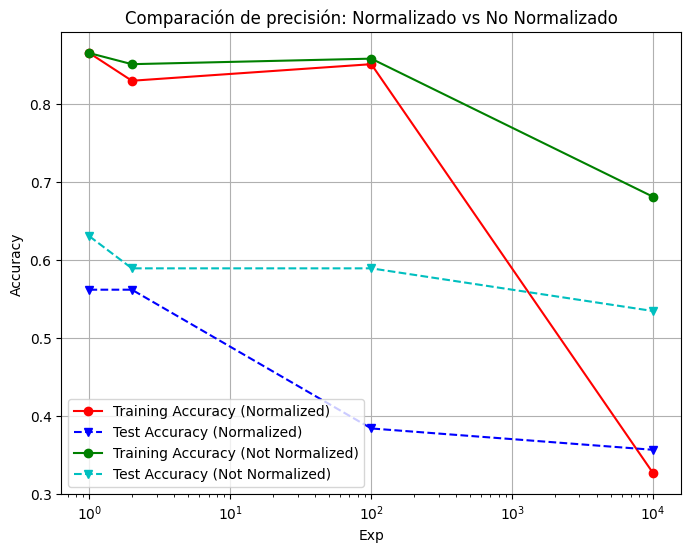

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Cargar datos
data = pd.read_csv('glass.csv')

Y = data['class']
X = data.drop(['class'], axis=1)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.34, random_state=10)

# Rango de experimentos
exp_range = [1, 2, 100, 10000]

trainAcc = np.zeros(len(exp_range))
testAcc = np.zeros(len(exp_range))

trainAccNor = np.zeros(len(exp_range))
testAccNor = np.zeros(len(exp_range))

index = 0 
for exp in exp_range:
    clf = kNN(k=3, exp=exp)

    # Normalizar los datos
    norm_x = clf.normalize(X_train)
    norm_xtest = clf.normalize(X_test)
    
    clf.fit(norm_x, Y_train)

    Y_predTrain = clf.getDiscreteClassification(norm_x)
    Y_predTest = clf.getDiscreteClassification(norm_xtest)

    trainAcc[index] = accuracy_score(Y_train, Y_predTrain)
    testAcc[index] = accuracy_score(Y_test, Y_predTest)

    # Entrenar sin normalizar
    clf.fit(X_train, Y_train)

    Y_predTrain = clf.getDiscreteClassification(X_train)
    Y_predTest = clf.getDiscreteClassification(X_test)

    trainAccNor[index] = accuracy_score(Y_train, Y_predTrain)
    testAccNor[index] = accuracy_score(Y_test, Y_predTest)

    index += 1

# Graficar resultados
plt.figure(figsize=(8, 6))
plt.plot(exp_range, trainAcc, 'ro-', label='Training Accuracy (Normalized)')
plt.plot(exp_range, testAcc, 'bv--', label='Test Accuracy (Normalized)')
plt.plot(exp_range, trainAccNor, 'go-', label='Training Accuracy (Not Normalized)')
plt.plot(exp_range, testAccNor, 'cv--', label='Test Accuracy (Not Normalized)')

plt.xlabel('Exp')
plt.ylabel('Accuracy')
plt.title('Comparación de precisión: Normalizado vs No Normalizado')
plt.legend()
plt.grid(True)
plt.xscale('log')  # Escala logarítmica para mejor visualización
plt.show()


### Mean Absolute Error (MAE) 

In [28]:
from sklearn.metrics import mean_absolute_error
y_true = [3, -0.5, 2, 7]
y_pred = [2.5, 0.0, 2, 8]
mean_absolute_error(y_true, y_pred)

0.5

# C. Añadir a la clase kNN el método getClassProbs que calcula para todas las instancias de prueba en X_test las probabilidades aposteriori de clase.

Primeras 5 instancias y sus probabilidades:
   prob_class_'build wind float'  prob_class_'build wind non-float'  \
0                       0.666667                           0.000000   
1                       1.000000                           0.000000   
2                       0.000000                           0.000000   
3                       0.333333                           0.666667   
4                       1.000000                           0.000000   

   prob_class_'vehic wind float'  prob_class_containers  prob_class_headlamps  \
0                       0.333333               0.000000              0.000000   
1                       0.000000               0.000000              0.000000   
2                       0.000000               0.333333              0.666667   
3                       0.000000               0.000000              0.000000   
4                       0.000000               0.000000              0.000000   

   prob_class_tableware  
0               

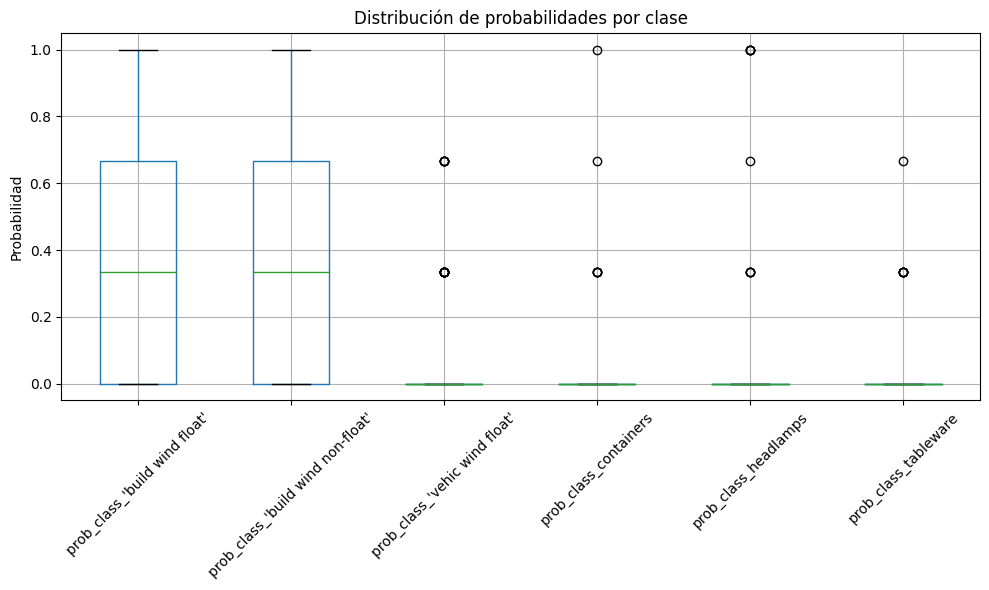

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Cargar y preparar los datos
data = pd.read_csv('glass.csv')
Y = data['class']
X = data.drop(['class'], axis=1)

# 2. Dividir en train y test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.34, random_state=10)

# 3. Crear y entrenar el clasificador kNN
clf = kNN(k=3)  # probamos con k=3
clf.fit(X_train, Y_train)

# 4. Obtener las probabilidades
probabilities = clf.getClassProbs(X_test)

# 5. Diferentes formas de analizar los resultados:

# Ver las primeras probabilidades
print("Primeras 5 instancias y sus probabilidades:")
print(probabilities.head())

# Ver la distribución de probabilidades para una instancia específica
print("\nProbabilidades para la primera instancia:")
print(probabilities.iloc[0])

# Obtener la clase con mayor probabilidad para cada instancia
predicted_classes = probabilities.idxmax(axis=1)
print("\nClases predichas para las primeras 5 instancias:")
print(predicted_classes.head())

# Comparar con las clases reales
print("\nComparación de predicciones vs valores reales:")
comparison = pd.DataFrame({
    'Clase Real': Y_test,
    'Clase Predicha': predicted_classes,
    'Probabilidad': probabilities.max(axis=1)
})
print(comparison.head())

# Visualizar la distribución de probabilidades
plt.figure(figsize=(10, 6))
probabilities.boxplot()
plt.title('Distribución de probabilidades por clase')
plt.ylabel('Probabilidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# E. Segmentación mediante KNN

El siguiente código presenta un ejemplo de como realizar la segmentación de imagenes implementado con scikit-image (skimage) y la técnica KNN de sklearn. Este modelo se basa en **clasificar pixeles**, por lo que los datos de entrada serán representaciones de pixeles y las etiquetas corresponden a las clases.

Utiliza imágenes de la base de datos ISIC sobre cáncer de piel con sus respectivas máscaras.

Nota: La ejecución puede tardar un tiempo considerable dependiendo del tamaño de la imagen, principalmente al usar extracción de características.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, feature, future
from sklearn.neighbors import KNeighborsClassifier
from functools import partial
from PIL import Image
import os

**Imagen de muestra**

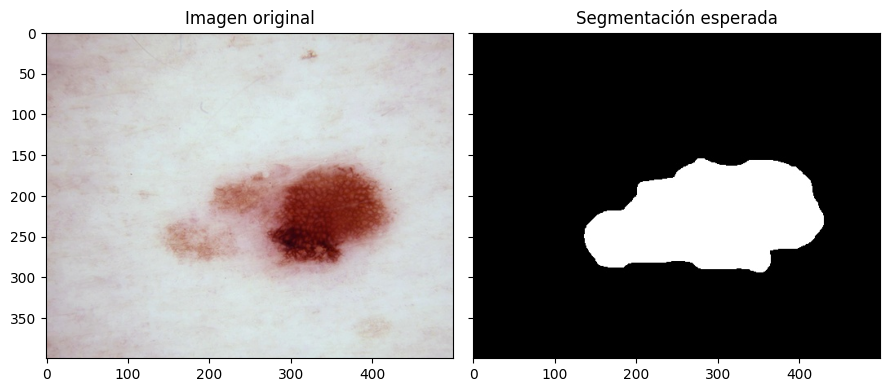

In [2]:
full_img = plt.imread("Images/ISIC_0024313.jpg")
image = Image.open('Images/ISIC_0024313_segmentation.jpg').convert("L")
segmented = np.asarray(image)

segm = segmented[:400, :500]
img = full_img[:400, :500]

fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(9, 4))
ax[0].imshow(img)
ax[0].set_title("Imagen original")
ax[1].imshow(segm, cmap='gray')
ax[1].set_title("Segmentación esperada")
fig.tight_layout()

Se asigna un valor por clase mediante regiones delimitadoras (cuadrados) para etiquetar pixeles de forma que signifique región de interés (posible melanoma) o piel. {1,2} respectivamente

In [3]:
training_labels = np.zeros(img.shape[:2], dtype=np.uint8)
training_labels[0:150 ,0:150] = 1
training_labels[200:250, 250:300] = 2

## Utilizando solo la imagen de prueba

Ejercicio. Divida todos los datos proporcionados (imágenes de melanoma) en conjuntos de entrenamiento y prueba. Replique el ejercicio de muestra con esos datos, es decir, implemente un clasificador KNN utilizando todas las imágenes en conjunto, recordando que la clasificación es por pixel. Pruebe diferentes valores para el hiperparamétro, explore la función para extraer características y varíe las coordenadas y tamaños de cuadros delimitadores para alguna imagen individual.

**Se** instancia un clasificador KNN (con sklearn) y 3 vecinos de hiperparámetro

In [4]:
clf = KNeighborsClassifier(n_neighbors=3)

Entrena con los valores de intensidad de las etiquetas antes asignadas en las regiones de la imagen

In [5]:
clf = future.fit_segmenter(training_labels, img, clf)

Se pedice la etiqueta para todos los pixeles de la imagen. Es decir, para los pixeles de entrenamiento y los de prueba (los que se incluyen en las regiones y los que no)

In [6]:
result = future.predict_segmenter(img, clf)

Se muestran los resultados

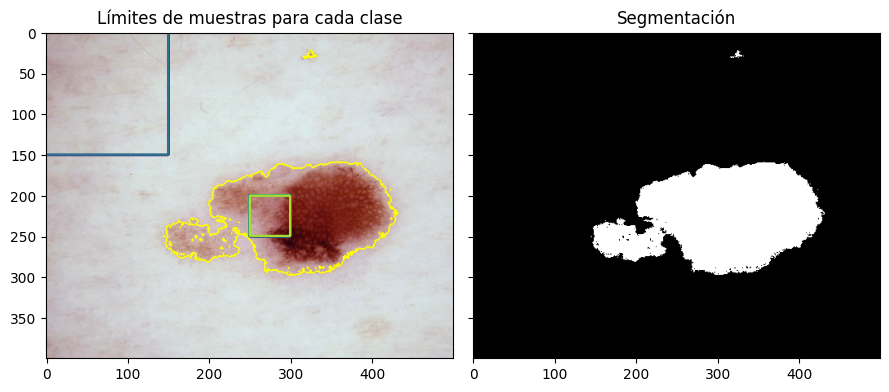

In [7]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(9, 4))
ax[0].imshow(segmentation.mark_boundaries(img, result, mode='thick'))
ax[0].contour(training_labels)
ax[0].set_title('Límites de muestras para cada clase')
ax[1].imshow(result, cmap='gray')
ax[1].set_title('Segmentación')
fig.tight_layout()

Se calcula métrica Intersección sobre Unión (IoU) o Índice de Jaccard contra la máscara de segmentación esperada para saber qué porcentaje de la segmentación es correcta

In [8]:
def calculaIoU(gtMask, predMask):
        # Calcula verdaderos positivos, falsos positivos, and falsos negativos
        tp = 0
        fp = 0
        fn = 0
        for i in range(len(gtMask)):
            for j in range(len(gtMask[0])):
                if gtMask[i][j] == 1 and predMask[i][j] == 2:
                    tp += 1
                elif gtMask[i][j] == 0 and predMask[i][j] == 2:
                    fp += 1
                elif gtMask[i][j] == 1 and predMask[i][j] == 1:
                    fn += 1

        # Calcula IoU
        iou = tp / (tp + fp + fn)

        return iou

In [9]:
print("El porcentaje de segmentación correcta es: {}%".format(round(1-calculaIoU(segm, result),4)*100))

El porcentaje de segmentación correcta es: 91.67%


## Utilizando extracción de características

Ejercicio. Divida todos los datos proporcionados (imágenes de melanoma) en conjuntos de entrenamiento y prueba. Replique el ejercicio de muestra con esos datos, es decir, implemente un clasificador KNN utilizando todas las imágenes en conjunto, recordando que la clasificación es por pixel. Pruebe diferentes valores para el hiperparamétro, explore la función para extraer características y varíe las coordenadas y tamaños de cuadros delimitadores para alguna imagen individual.

Segmentación no encontrada para ISIC_0024351_segmentation_segmentation.jpg
Segmentación no encontrada para ISIC_0024481_segmentation_segmentation.jpg
Segmentación no encontrada para ISIC_0024313_segmentation_segmentation.jpg
Segmentación no encontrada para ISIC_0024496_segmentation_segmentation.jpg


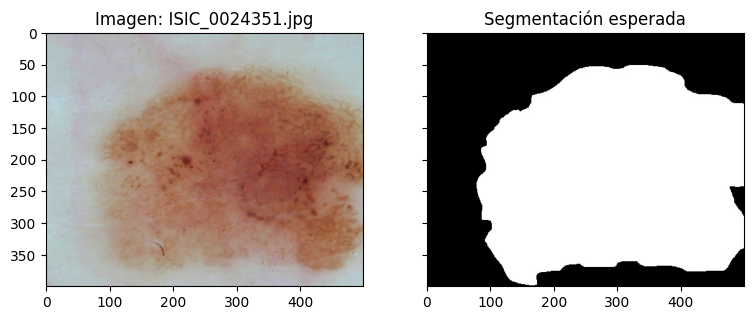

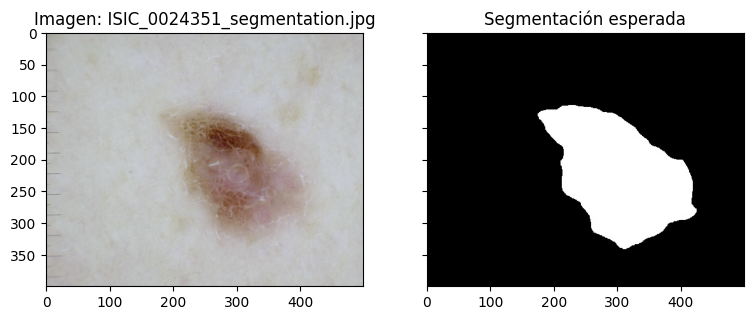

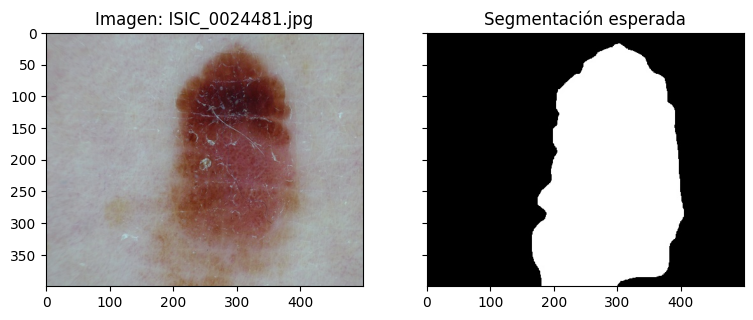

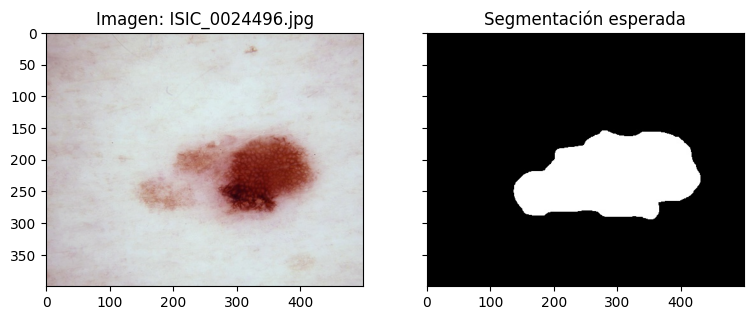

Probando K = 1


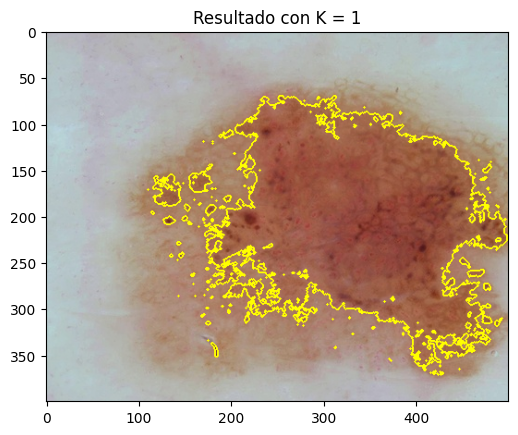

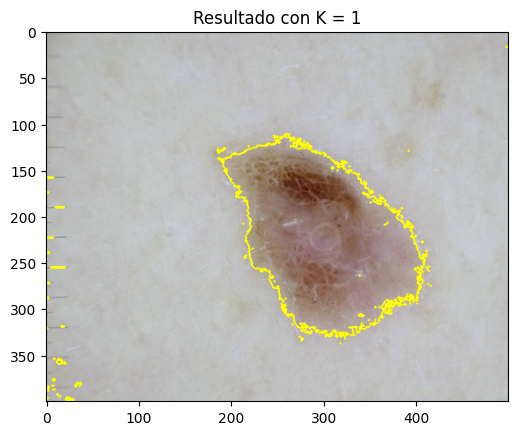

Probando K = 3


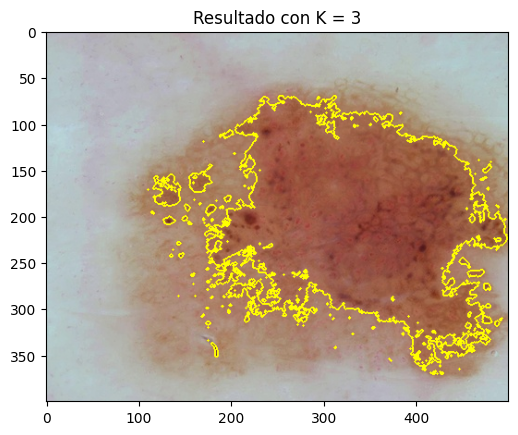

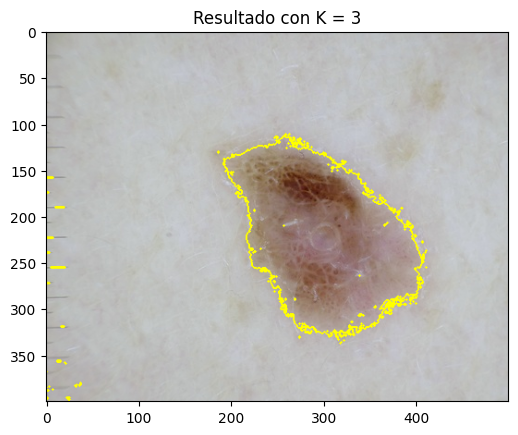

Probando K = 5


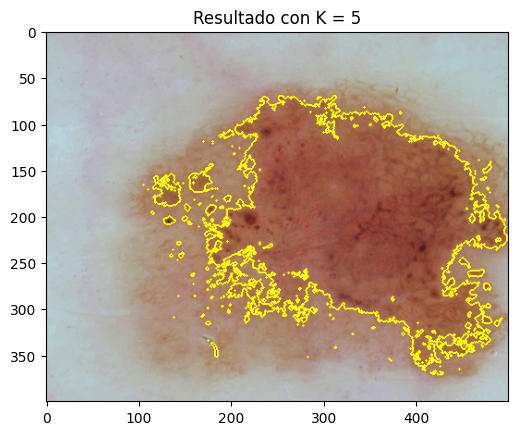

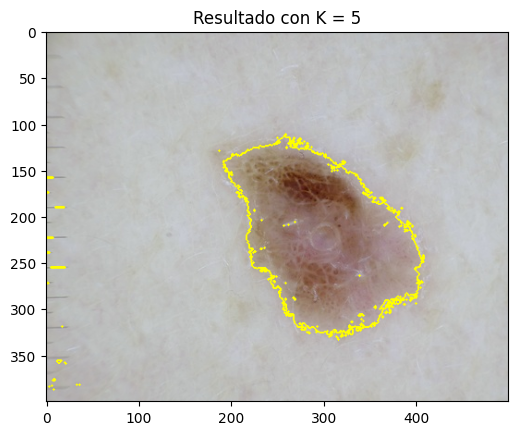

Probando K = 7


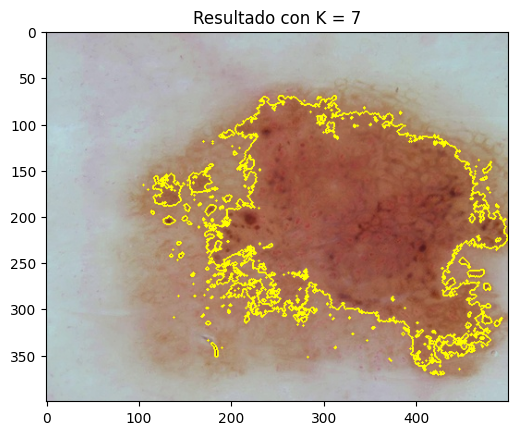

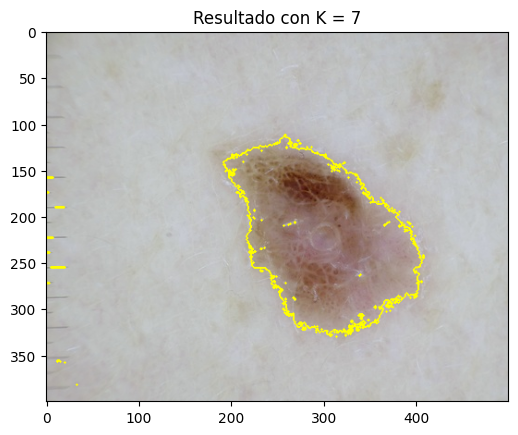

Resultados: {'K=1': 94.89999999999999, 'K=3': 95.42, 'K=5': 96.55, 'K=7': 97.96000000000001}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import segmentation, feature, future
from sklearn.neighbors import KNeighborsClassifier
from functools import partial
from PIL import Image
import os

# Función para cargar imágenes y sus segmentaciones desde el directorio por defecto de Colab
def cargar_imagenes():
    imagenes = []
    segmentaciones = []
    ruta_imagenes = "Images"  # Nuevo directorio donde están las imágenes
    nombres = [f for f in os.listdir(ruta_imagenes) if f.endswith('.jpg')]
    
    for nombre in nombres:
        img_ruta = os.path.join(ruta_imagenes, nombre)
        img = plt.imread(img_ruta)
        
        segm_nombre = nombre.replace('.jpg', '_segmentation.jpg')  
        segm_ruta = os.path.join(ruta_imagenes, segm_nombre)
        
        if os.path.exists(segm_ruta):
            segm = plt.imread(segm_ruta)
            imagenes.append(img[:400, :500])
            segmentaciones.append(np.asarray(segm)[:400, :500])
        else:
            print(f"Segmentación no encontrada para {segm_nombre}")
    
    return imagenes, segmentaciones, nombres


# Función para mostrar las imágenes y segmentaciones
def mostrar_imagenes(imagenes, segmentaciones, nombres):
    for img, segm, nombre in zip(imagenes, segmentaciones, nombres):
        fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(9, 4))
        ax[0].imshow(img)
        ax[0].set_title(f"Imagen: {nombre}")
        ax[1].imshow(segm, cmap='gray')
        ax[1].set_title("Segmentación esperada")
        plt.show()

# Función para etiquetar píxeles manualmente
def etiquetar_pixeles(img):
    labels = np.zeros(img.shape[:2], dtype=np.uint8)
    labels[0:150, 0:150] = 1  # Melanoma
    labels[200:250, 250:300] = 2  # Piel
    return labels

# Función para entrenar y predecir usando KNN
def entrenar_predecir_knn(img, labels, k):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf = future.fit_segmenter(labels, img, clf)
    result = future.predict_segmenter(img, clf)
    return result

# Función para calcular IoU
def calculaIoU(gtMask, predMask):
    if len(gtMask.shape) == 3:  # Si la segmentación tiene 3 canales (RGB)
        gtMask = gtMask[:, :, 0]  # Usar solo un canal
    if len(predMask.shape) == 3:
        predMask = predMask[:, :, 0]

    tp = np.sum((gtMask == 1) & (predMask == 2))
    fp = np.sum((gtMask == 0) & (predMask == 2))
    fn = np.sum((gtMask == 1) & (predMask == 1))
    iou = tp / (tp + fp + fn + 1e-10)  # Añadir epsilon para evitar divisiones entre 0
    return iou

# División de datos (simplemente 2 para entrenamiento y 1 para prueba)
def dividir_datos(imagenes, segmentaciones):
    return imagenes[:2], segmentaciones[:2], imagenes[2:], segmentaciones[2:]

# Probar diferentes valores de K
def probar_diferentes_k(imagenes, segmentaciones, ks=[1, 3, 5, 7]):
    resultados = {}
    for k in ks:
        print(f"Probando K = {k}")
        for img, segm in zip(imagenes, segmentaciones):
            labels = etiquetar_pixeles(img)
            result = entrenar_predecir_knn(img, labels, k)
            iou = calculaIoU(segm, result)
            resultados[f"K={k}"] = round(1 - iou, 4) * 100
            plt.imshow(segmentation.mark_boundaries(img, result, mode='thick'))
            plt.title(f"Resultado con K = {k}")
            plt.show()
    print("Resultados:", resultados)

# Main
imagenes, segmentaciones, nombres = cargar_imagenes()
mostrar_imagenes(imagenes, segmentaciones, nombres)

imagenes_entrenamiento, segm_entrenamiento, imagenes_prueba, segm_prueba = dividir_datos(imagenes, segmentaciones)

probar_diferentes_k(imagenes_entrenamiento, segm_entrenamiento)

